In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))


In [2]:
import src.classifier as cl
import src.candidates as can
import src.features as f
import src.utils as u
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [3]:
model_path = Path("../models/random_forest_v1.joblib")
WallClassifier = cl.WallClassifier(model_path)

In [4]:
input_img_path = "../data/test_ds/test4.jpg"
image = cv2.imread(input_img_path)
img_name = os.path.basename(input_img_path).split('.')[0]

In [5]:
candidate_coords = can.get_combined_candidates(image)

features_stack = f.extract_features(image)

In [6]:
len(candidate_coords)

194

In [7]:
feature_patches = []

counter = 0
for coords in candidate_coords:
    x, y = coords
    
    patch = u.extract_patch(features_stack, x, y, 64)
    
    feature_patches.append(patch)
    
    counter += 1
    if counter == 200:
        break

In [8]:
X_inference = np.array(feature_patches)

In [9]:
X_inference.shape

(194, 64, 64, 13)

In [10]:
X_inference_processed = u.preprocess_patches_dataset(X_inference)

In [11]:
preds = WallClassifier.predict(X_inference_processed)

In [12]:
HOLD_HOLE_ID = 1
WALL_HOLE_ID = 2

wall_holes = []
hold_holes = []

for kp, prediction in zip(candidate_coords, preds):
    if prediction == HOLD_HOLE_ID:
        hold_holes.append(kp)
        
    if prediction == WALL_HOLE_ID:
        wall_holes.append(kp)

print(f"Candidates: {len(candidate_coords)} -> Wall Holes: {len(wall_holes)}; Hold Holes: {len(hold_holes)}")

Candidates: 194 -> Wall Holes: 96; Hold Holes: 31


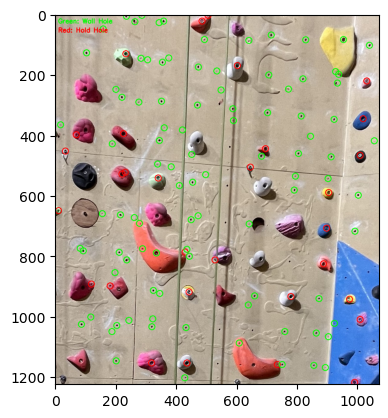

In [13]:
vis_img = image.copy()

for (x, y) in hold_holes:
    cv2.circle(vis_img, (int(x), int(y)), radius=10, color=(0, 0, 255), thickness=2)

for (x, y) in wall_holes:
    cv2.circle(vis_img, (int(x), int(y)), radius=10, color=(0, 255, 0), thickness=2)

cv2.putText(vis_img, "Green: Wall Hole", (10, 30), 
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
cv2.putText(vis_img, "Red: Hold Hole ", (10, 60), 
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))

In [14]:
wall_holes

[(433, 1037),
 (913, 472),
 (189, 429),
 (904, 1067),
 (760, 1050),
 (938, 199),
 (894, 1169),
 (450, 680),
 (320, 1034),
 (264, 25),
 (325, 914),
 (1040, 103),
 (104, 128),
 (751, 1159),
 (118, 1002),
 (93, 783),
 (928, 190),
 (795, 536),
 (856, 1162),
 (202, 1147),
 (216, 664),
 (474, 175),
 (289, 776),
 (87, 1026),
 (345, 418),
 (287, 4),
 (641, 87),
 (411, 567),
 (339, 496),
 (549, 251),
 (83, 775),
 (212, 788),
 (188, 1050),
 (590, 352),
 (444, 801),
 (352, 288),
 (361, 376),
 (1003, 599),
 (814, 337),
 (934, 228),
 (791, 582),
 (642, 694),
 (18, 366),
 (1056, 419),
 (992, 718),
 (494, 84),
 (421, 383),
 (903, 544),
 (535, 188),
 (829, 85),
 (344, 28),
 (473, 667),
 (279, 692),
 (452, 464),
 (683, 470),
 (845, 404),
 (355, 159),
 (609, 1088),
 (660, 932),
 (204, 1030),
 (159, 49),
 (376, 145),
 (156, 660),
 (429, 1203),
 (707, 201),
 (436, 778),
 (346, 924),
 (954, 84),
 (772, 248),
 (244, 1013),
 (201, 249),
 (588, 313),
 (471, 301),
 (306, 151),
 (262, 673),
 (221, 275),
 (359, 

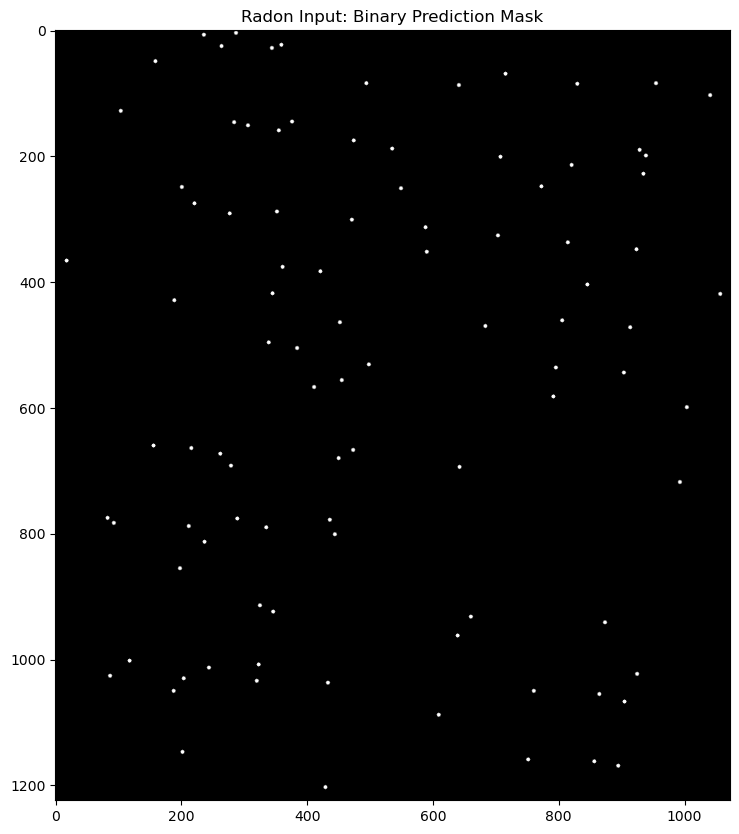

In [15]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def create_binary_mask(points, image_shape, dot_radius=3):

    h, w = image_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    # 2. Iterate and draw
    for point in points:
        x, y = point
        
        # Sanity check: ensure point is within image bounds
        if 0 <= x < w and 0 <= y < h:

            cv2.circle(mask, (x, y), dot_radius, 255, -1)
    
    return mask

binary_matrix = create_binary_mask(wall_holes, image.shape)

# 4. Visualize
plt.figure(figsize=(10, 10))
plt.title("Radon Input: Binary Prediction Mask")
plt.imshow(binary_matrix, cmap='gray')
plt.show()

In [22]:
import numpy as np
import cv2

def create_scaled_mask(points, original_shape, target_dim=512, dot_radius=2):
    h, w = original_shape[:2]
    scale_factor = target_dim / max(h, w)
    new_w = int(w * scale_factor)
    new_h = int(h * scale_factor)
    
    mask = np.zeros((new_h, new_w), dtype=np.uint8)
    
    for point in points:
        sx = int(point[0] * scale_factor)
        sy = int(point[1] * scale_factor)
        
        if 0 <= sx < new_w and 0 <= sy < new_h:
            cv2.circle(mask, (sx, sy), dot_radius, 255, -1)
            
    return mask, scale_factor

# Usage
radon_input, scale = create_scaled_mask(wall_holes, image.shape)

c:\Users\yana\anaconda3\envs\dyno_or_no\Lib\site-packages\skimage\transform\radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


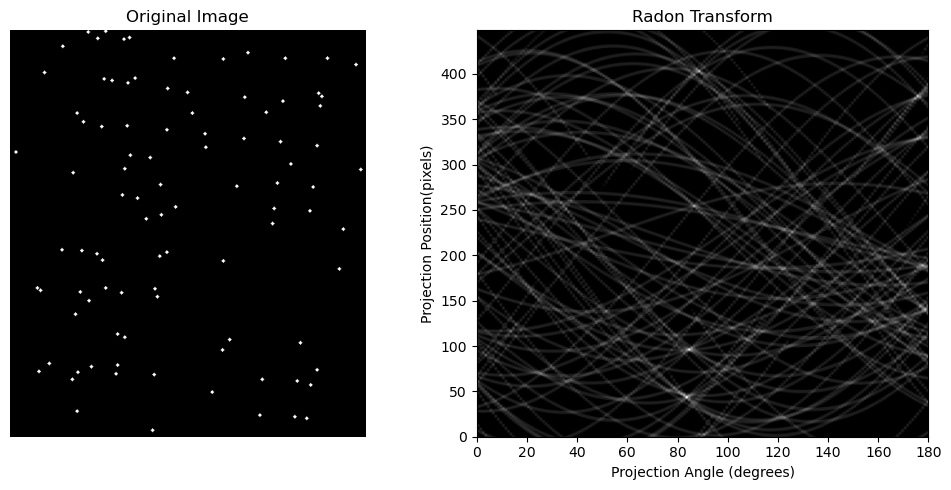

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import transform, io

theta = np.linspace(0, 180, 180, endpoint=False)

# Perform Radon transform
sinogram = transform.radon(radon_input, theta=theta)

# Perform inverse Radon transform using Filtered Back Projection algorithm
reconstructed = transform.iradon(sinogram , theta=theta)

# Plot the original and transformed images side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(radon_input, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(sinogram, cmap='gray', aspect='auto', extent=(0, 180, 0, sinogram.shape[0]))
axes[1].set_title('Radon Transform')
axes[1].set_xlabel('Projection Angle (degrees)')
axes[1].set_ylabel('Projection Position(pixels)')
plt.tight_layout()
plt.show()

In [26]:
sinogram

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.3802555 , 2.6928181 , ..., 2.83187079, 3.92666364,
        0.7643254 ],
       [0.        , 0.        , 0.69369444, ..., 4.78231753, 1.92422844,
        0.        ],
       [0.        , 0.        , 0.        , ..., 3.20834172, 0.4612012 ,
        0.        ]], shape=(448, 180))

In [27]:
from skimage.feature import peak_local_max
peaks = peak_local_max(sinogram, min_distance=20, threshold_rel=0.3)

In [28]:
peaks

array([[404,  83],
       [351,  84],
       [ 45,  88],
       [193,  86],
       [296, 124],
       [222, 125],
       [180,  21],
       [263, 121],
       [193, 133],
       [373,  98],
       [377,  25],
       [340, 107],
       [105,  68],
       [309,  51],
       [137,  59],
       [426, 122],
       [ 74,  42],
       [339,  56],
       [144,  87],
       [221,  28],
       [283,  59],
       [256,  79],
       [170, 127],
       [285,  89],
       [286,  21],
       [124, 108],
       [387, 149]])

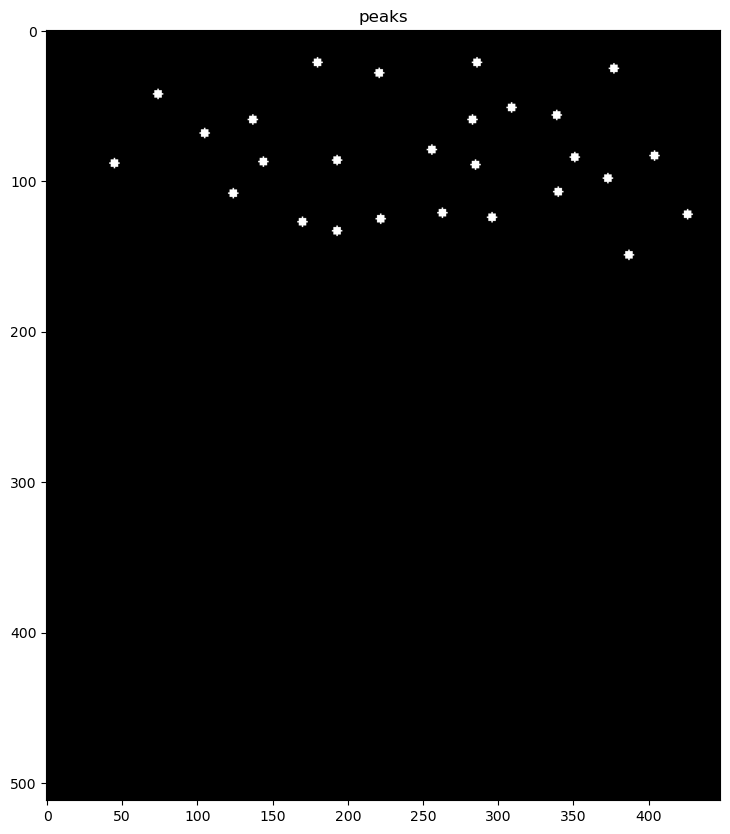

In [31]:
peaks_bin = create_binary_mask(peaks, radon_input.shape)

# 4. Visualize
plt.figure(figsize=(10, 10))
plt.title("peaks")
plt.imshow(peaks_bin, cmap='gray')
plt.show()